<a href="https://colab.research.google.com/github/ayush4628/Movie-Review-Sentiment-Analysis/blob/main/Movie_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [2]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [3]:
data = pd.read_csv('/content/drive/MyDrive/Datasets/IMDB_Dataset.csv')

In [4]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
data.shape

(50000, 2)

In [6]:
type(data)

pandas.core.frame.DataFrame

In [7]:
data.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


In [8]:
data.isnull().sum()

,0
review,0
sentiment,0


In [9]:
data.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [10]:
data['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [11]:
# One Hot Encoder
# Label Encoder

In [12]:
# Positive --> 1
# Negative --> 0

data.replace({'sentiment': {'positive': 1, 'negative': 0}}, inplace=True)

In [13]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [14]:
data.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,1
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",0
49997,I am a Catholic taught in parochial elementary...,0
49998,I'm going to have to disagree with the previou...,0
49999,No one expects the Star Trek movies to be high...,0


In [15]:
data['sentiment'].value_counts()

,count
sentiment,
1,25000
0,25000


In [16]:
data['word_count'] = data['review'].apply(lambda x: len(x.split()))

In [17]:
data['word_count'].describe()

,word_count
count,50000.000000
mean,231.156940
std,171.343997
min,4.000000
25%,126.000000
50%,173.000000
75%,280.000000
max,2470.000000


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

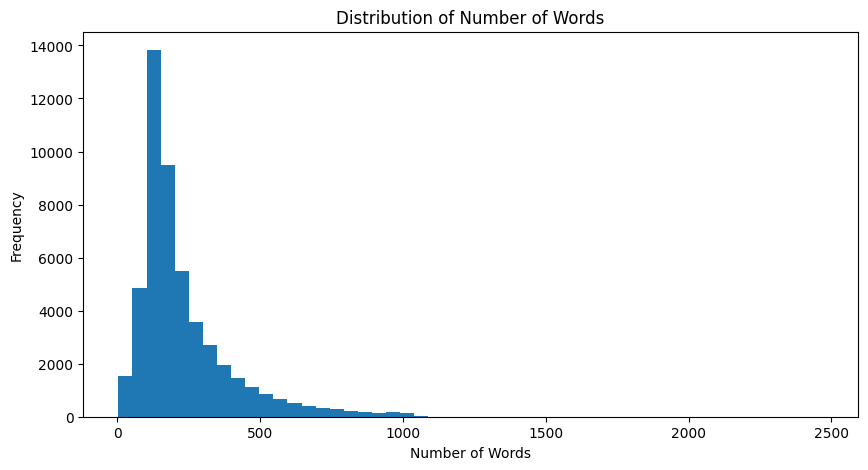

In [19]:
plt.figure(figsize=(10,5))

plt.hist(data['word_count'], bins=50)

plt.title("Distribution of Number of Words")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

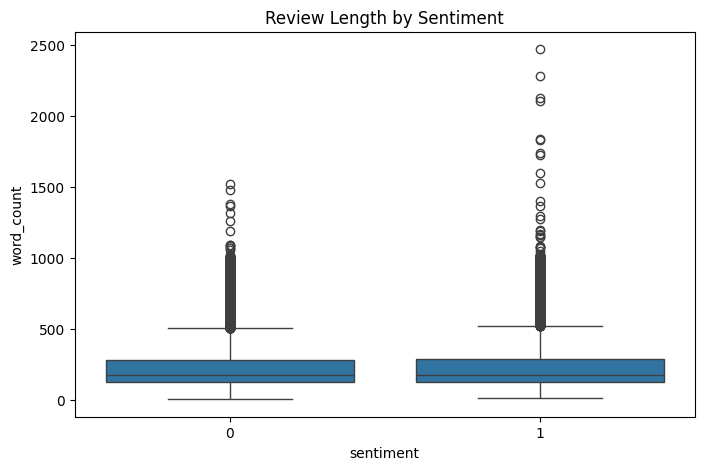

In [20]:
# Compare review length by sentiment

plt.figure(figsize=(8,5))

sns.boxplot(
    data=data,
    x='sentiment',
    y='word_count'
)

plt.title("Review Length by Sentiment")

plt.show()

## **Text-Preprocessing**

In [21]:
import re
import string

In [22]:
def clean_text(text):

    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    # Remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [23]:
data['clean_review'] = data['review'].apply(clean_text)

In [24]:
data[['review', 'clean_review']].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,basically theres a family where a little boy j...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love in the time of money is a ...


In [25]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, Input, SimpleRNN, LSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [26]:
X = data['clean_review']
y = data['sentiment']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [28]:
X_train.shape, X_test.shape

((40000,), (10000,))

In [29]:
y_train.shape, y_test.shape

((40000,), (10000,))

## **Create Validation set**

In [30]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

In [31]:
vocab_size = 20000

tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token="<OOV>"
)

In [32]:
tokenizer.fit_on_texts(X_train)

In [33]:
word_index = tokenizer.word_index

list(word_index.items())[:20]

[('<OOV>', 1),
 ('the', 2),
 ('a', 3),
 ('and', 4),
 ('of', 5),
 ('to', 6),
 ('is', 7),
 ('in', 8),
 ('it', 9),
 ('i', 10),
 ('this', 11),
 ('that', 12),
 ('was', 13),
 ('as', 14),
 ('with', 15),
 ('for', 16),
 ('movie', 17),
 ('but', 18),
 ('film', 19),
 ('on', 20)]

In [34]:
#  Convert text into sequences

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [35]:
X_train_seq[0][:20]

[437,
 434,
 10,
 25,
 6,
 1006,
 15,
 2,
 375,
 35,
 1635,
 11,
 14,
 3330,
 2,
 113,
 8,
 11,
 684,
 563]

In [36]:
# Find suitable sequence length

train_lengths = X_train.apply(lambda x: len(x.split()))
train_lengths.describe(percentiles=[0.5, 0.75, 0.90, 0.95, 0.99])

,clean_review
count,32000.000000
mean,228.076906
std,168.747323
min,8.000000
50%,171.000000
75%,277.000000
90%,446.000000
95%,583.000000
99%,889.010000
max,2459.000000


In [37]:
max_length = 600

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding='post',
    truncating='post'
)



In [38]:
X_train_pad.shape

(32000, 600)

## **SimpleRNN**

In [39]:
model = Sequential([
    Input(shape=(max_length,)),
    Embedding(input_dim=vocab_size, output_dim=128),
    SimpleRNN(128, return_sequences=False),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [40]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [41]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 600, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,601,217 (9.92 MB)

 Trainable params: 2,601,217 (9.92 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
# Train the Model

history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=64
)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 30s 52ms/step - accuracy: 0.4991 - loss: 0.7389 - val_accuracy: 0.5092 - val_loss: 0.6935
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 50ms/step - accuracy: 0.4984 - loss: 0.6995 - val_accuracy: 0.5082 - val_loss: 0.6930
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 26s 53ms/step - accuracy: 0.4959 - loss: 0.6949 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 51ms/step - accuracy: 0.5027 - loss: 0.6942 - val_accuracy: 0.4991 - val_loss: 0.6931
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step - accuracy: 0.4984 - loss: 0.6942 - val_accuracy: 0.4997 - val_loss: 0.6932
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step - accuracy: 0.5031 - loss: 0.6941 - val_accuracy: 0.4971 - val_loss: 0.6932
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 50ms/step - accuracy: 0.4972 - loss: 0.6941 - val_accuracy: 0.5069 - val_loss: 0.6930
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 50ms/step - accuracy: 0.4969 - loss: 0.6943 - 

In [43]:
# Early Stopping

from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor = 'val_loss',
    patience = 3,
    restore_best_weights=True
)

In [44]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=64,
    callbacks=[early_stopping]
)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 55ms/step - accuracy: 0.4983 - loss: 0.6940 - val_accuracy: 0.5132 - val_loss: 0.6929
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 0.4985 - loss: 0.6938 - val_accuracy: 0.5105 - val_loss: 0.6929
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 37s 56ms/step - accuracy: 0.5058 - loss: 0.6935 - val_accuracy: 0.5045 - val_loss: 0.6931
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 26s 52ms/step - accuracy: 0.5048 - loss: 0.6935 - val_accuracy: 0.5024 - val_loss: 0.6930
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 26s 52ms/step - accuracy: 0.5052 - loss: 0.6933 - val_accuracy: 0.5095 - val_loss: 0.6928
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 29s 58ms/step - accuracy: 0.5008 - loss: 0.6928 - val_accuracy: 0.5059 - val_loss: 0.6929
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 37s 51ms/step - accuracy: 0.5039 - loss: 0.6926 - val_accuracy: 0.5070 - val_loss: 0.6930
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 51ms/step - accuracy: 0.5041 - loss: 0.6926 - 

## **SimpleRNN(Plot training history)**

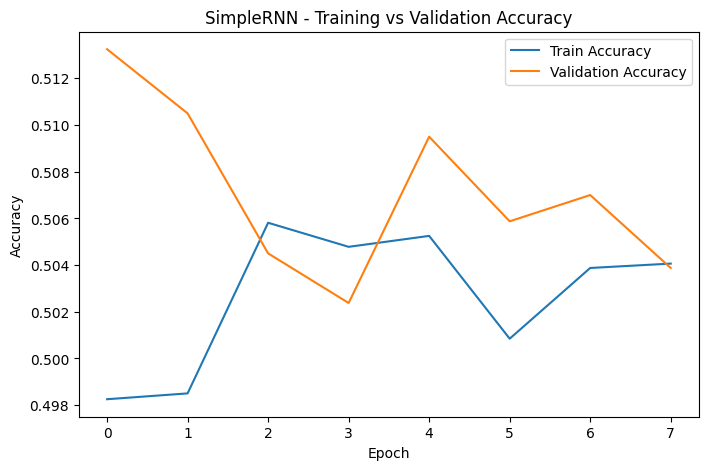

In [45]:
# Accuracy

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("SimpleRNN - Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.show()

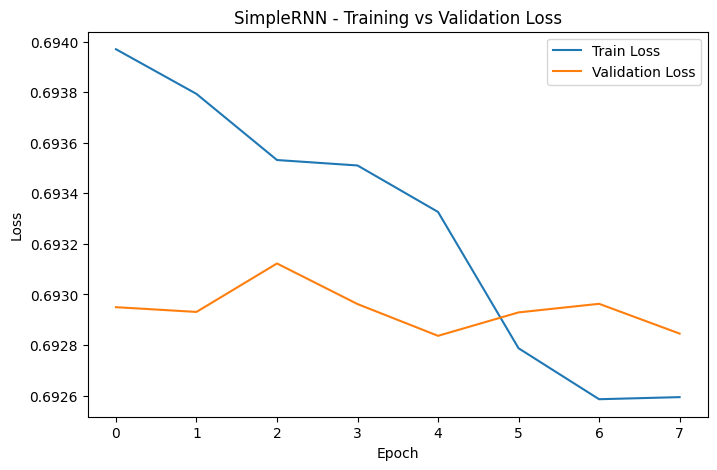

In [46]:
# Loss

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("SimpleRNN - Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [47]:
# Evaluate on test data

test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.5056 - loss: 0.6931
Test Loss: 0.6930606961250305
Test Accuracy: 0.5055999755859375


In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


In [49]:
y_prob = model.predict(X_test_pad)

y_pred = (y_prob >= 0.5).astype(int).ravel()

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step


In [50]:
print(confusion_matrix(y_test, y_pred))

[[4174  826]
 [4118  882]]


In [51]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.5056
Precision: 0.5163934426229508
Recall   : 0.1764
F1 Score : 0.2629695885509839


# **LSTM**

In [52]:
lstm_model = Sequential([
    Input(shape=(max_length,)),
    Embedding(input_dim=vocab_size, output_dim=128, mask_zero=True), # Mask Zero tells Ignore the padding tokens
    LSTM(128),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [53]:
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 600, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,699,905 (10.30 MB)

 Trainable params: 2,699,905 (10.30 MB)

 Non-trainable params: 0 (0.00 B)

In [54]:
lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [63]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [64]:
lstm_history = lstm_model.fit(
    X_train_pad,
    y_train, validation_data=(
        X_val_pad,
        y_val
    ),

    epochs=10,
    batch_size=64,

    callbacks=[
        early_stopping
    ]
)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.9323 - loss: 0.1921 - val_accuracy: 0.8715 - val_loss: 0.3259
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.9544 - loss: 0.1337 - val_accuracy: 0.8719 - val_loss: 0.3965
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.9657 - loss: 0.1024 - val_accuracy: 0.8695 - val_loss: 0.4058


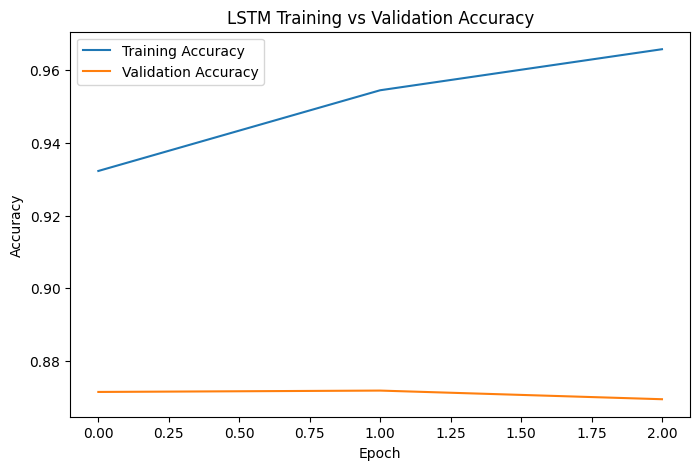

In [65]:
plt.figure(figsize=(8, 5))

plt.plot(
    lstm_history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    lstm_history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('LSTM Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

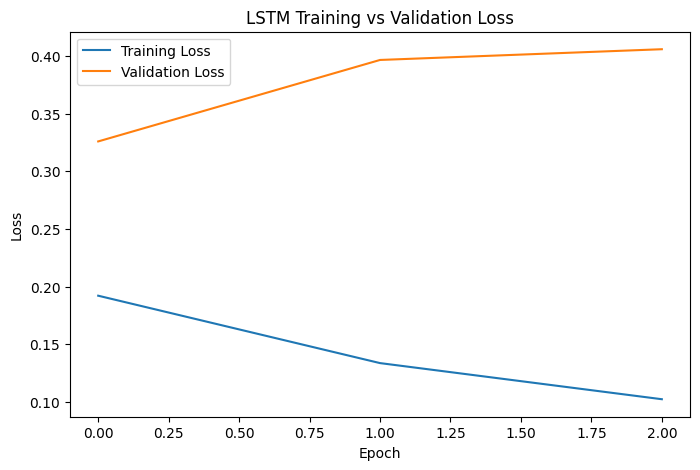

In [66]:
plt.figure(figsize=(8, 5))

plt.plot(
    lstm_history.history['loss'],
    label='Training Loss'
)

plt.plot(
    lstm_history.history['val_loss'],
    label='Validation Loss'
)

plt.title('LSTM Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [67]:
lstm_loss, lstm_accuracy = lstm_model.evaluate(
    X_test_pad,
    y_test,
    verbose=1
)

print("LSTM Test Loss:", lstm_loss)
print("LSTM Test Accuracy:", lstm_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8805 - loss: 0.3132
LSTM Test Loss: 0.3131626844406128
LSTM Test Accuracy: 0.8805000185966492


In [68]:
lstm_prob = lstm_model.predict(X_test_pad)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step


In [69]:
lstm_pred = (lstm_prob >= 0.5).astype(int).ravel()

In [82]:
print("confusion_matrix: \n", confusion_matrix(y_test, lstm_pred))

confusion_matrix: 
 [[4464  536]
 [ 659 4341]]


In [70]:
lstm_accuracy = accuracy_score(y_test, lstm_pred)

lstm_precision = precision_score(y_test, lstm_pred)

lstm_recall = recall_score(y_test, lstm_pred)

lstm_f1 = f1_score(y_test, lstm_pred)

print("LSTM Accuracy :", lstm_accuracy)
print("LSTM Precision:", lstm_precision)
print("LSTM Recall   :", lstm_recall)
print("LSTM F1 Score :", lstm_f1)

LSTM Accuracy : 0.8805
LSTM Precision: 0.8900963707197047
LSTM Recall   : 0.8682
LSTM F1 Score : 0.8790118457021363


# **GRU**

In [72]:
from tensorflow.keras.layers import GRU

In [73]:
gru_model = Sequential([

    Input(shape=(max_length,)),
    Embedding(input_dim=vocab_size, output_dim=128, mask_zero=True),
    GRU(128),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [74]:
gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 600, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,667,393 (10.18 MB)

 Trainable params: 2,667,393 (10.18 MB)

 Non-trainable params: 0 (0.00 B)

In [75]:
gru_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [76]:
gru_history = gru_model.fit(
    X_train_pad,
    y_train,

    validation_data=(
        X_val_pad,
        y_val
    ),

    epochs=10,
    batch_size=64,

    callbacks=[
        early_stopping
    ]
)

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 34ms/step - accuracy: 0.7700 - loss: 0.4677 - val_accuracy: 0.8873 - val_loss: 0.2841
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.9139 - loss: 0.2315 - val_accuracy: 0.9024 - val_loss: 0.2445
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.9567 - loss: 0.1311 - val_accuracy: 0.8981 - val_loss: 0.2670
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.9764 - loss: 0.0738 - val_accuracy: 0.8932 - val_loss: 0.3780


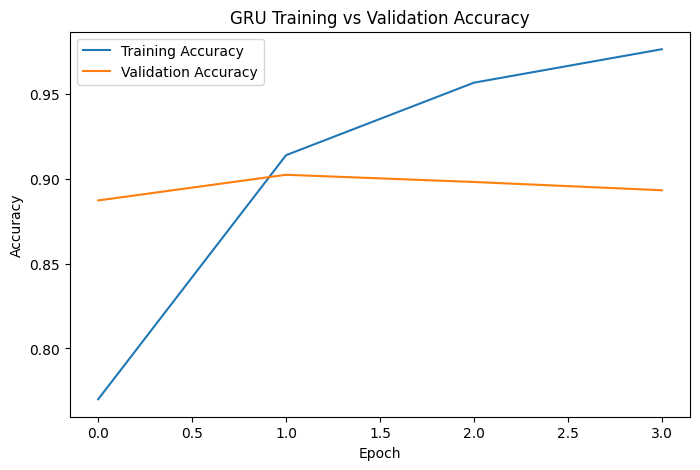

In [77]:
plt.figure(figsize=(8, 5))

plt.plot(
    gru_history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    gru_history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('GRU Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

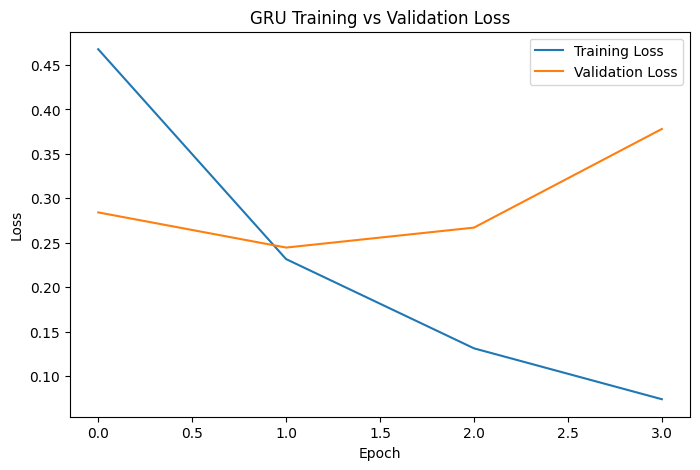

In [78]:
plt.figure(figsize=(8, 5))

plt.plot(
    gru_history.history['loss'],
    label='Training Loss'
)

plt.plot(
    gru_history.history['val_loss'],
    label='Validation Loss'
)

plt.title('GRU Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [79]:
gru_loss, gru_accuracy = gru_model.evaluate(
    X_test_pad,
    y_test,
    verbose=1
)

print("GRU Test Loss:", gru_loss)
print("GRU Test Accuracy:", gru_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9034 - loss: 0.2415
GRU Test Loss: 0.24145080149173737
GRU Test Accuracy: 0.9034000039100647


In [80]:
gru_prob = gru_model.predict( X_test_pad)

gru_pred = (gru_prob >= 0.5).astype(int).ravel()

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


In [83]:
print("confusion_matrix: \n", confusion_matrix(y_test, gru_pred))

confusion_matrix: 
 [[4595  405]
 [ 561 4439]]


In [81]:
gru_accuracy = accuracy_score(y_test, gru_pred)

gru_precision = precision_score(y_test, gru_pred)

gru_recall = recall_score(y_test, gru_pred)

gru_f1 = f1_score(y_test,gru_pred)

print("GRU Accuracy :", gru_accuracy)
print("GRU Precision:", gru_precision)
print("GRU Recall   :", gru_recall)
print("GRU F1 Score :", gru_f1)

GRU Accuracy : 0.9034
GRU Precision: 0.9163914120561519
GRU Recall   : 0.8878
GRU F1 Score : 0.9018691588785047


## **Now camparidon all model**

In [90]:
rnn_accuracy = accuracy_score(y_test, y_pred)
rnn_precision = precision_score(y_test, y_pred)
rnn_recall = recall_score(y_test, y_pred)
rnn_f1 = f1_score(y_test, y_pred)

In [92]:
comparison = pd.DataFrame({'Model': ['SimpleRNN', 'LSTM', 'GRU'],

    'Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy],

    'Precision': [rnn_precision ,lstm_precision, gru_precision],

    'Recall': [rnn_recall, lstm_recall, gru_recall],

    'F1 Score': [rnn_f1, lstm_f1, gru_f1]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,SimpleRNN,0.5056,0.516393,0.1764,0.262970
1,LSTM,0.8805,0.890096,0.8682,0.879012
2,GRU,0.9034,0.916391,0.8878,0.901869



**Model Comparison:** SimpleRNN, LSTM, and GRU were evaluated on the IMDB sentiment classification dataset using the same preprocessing and evaluation setup. SimpleRNN performed poorly with an F1 score of 26.30%, indicating difficulty in capturing long-term dependencies in lengthy movie reviews. LSTM significantly improved performance, achieving 88.05% accuracy and an F1 score of 87.90%. GRU achieved the best performance with 90.34% accuracy, 91.64% precision, 88.78% recall, and 90.19% F1 score. Therefore, GRU was selected as the best-performing recurrent architecture for this experiment.

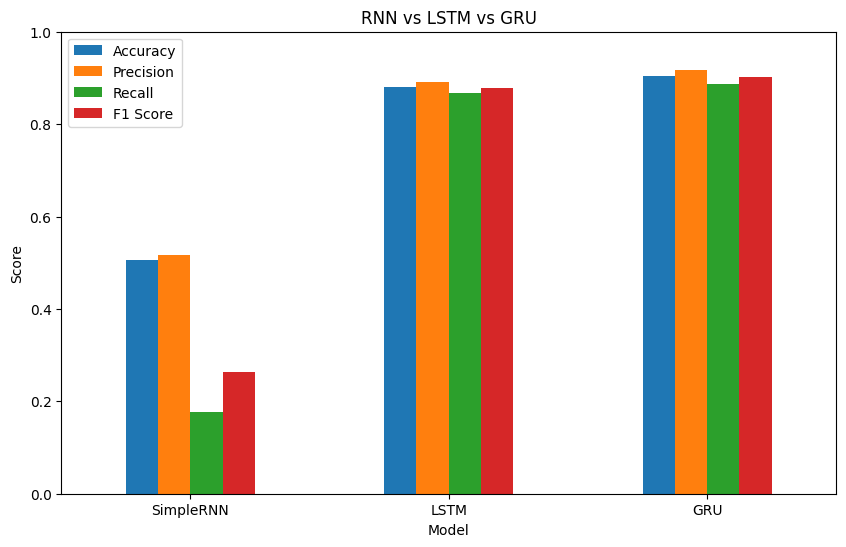

In [93]:
comparison.set_index(
    'Model'
)[
    ['Accuracy', 'Precision', 'Recall', 'F1 Score']
].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('RNN vs LSTM vs GRU')
plt.ylabel('Score')
plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.show()

##**Test Our Model**

In [101]:
def predict_review(review):

    # 1. Clean the review
    cleaned_review = clean_text(review)

    # 2. Convert text to sequence
    sequence = tokenizer.texts_to_sequences([cleaned_review])

    # 3. Padding
    padded_sequence = pad_sequences(
        sequence,
        maxlen=max_length,
        padding='post',
        truncating='post'
    )

    # 4. Prediction using GRU
    probability = gru_model.predict(
        padded_sequence,
        verbose=0
    )[0][0]

    # 5. Convert probability to sentiment
    if probability >= 0.5:
        sentiment = "Positive"
        confidence = probability
    else:
        sentiment = "Negative"
        confidence = 1 - probability

    print("Review:")
    print(review)
    print()
    print("Predicted Sentiment :", sentiment)
    print("Confidence          :", round(float(confidence) * 100, 2), "%")

In [102]:
review = """
This movie was absolutely amazing.
The story was fantastic, the acting was brilliant,
and I really enjoyed watching it.
"""

predict_review(review)

Review:

This movie was absolutely amazing. 
The story was fantastic, the acting was brilliant,
and I really enjoyed watching it.


Predicted Sentiment : Positive
Confidence          : 98.98 %


In [104]:
review = """
The movie started very well and I really enjoyed the first half,
but the second half was extremely boring and disappointing.
"""

predict_review(review)

Review:

The movie started very well and I really enjoyed the first half,
but the second half was extremely boring and disappointing.


Predicted Sentiment : Negative
Confidence          : 97.0 %


#**Save the Model**

In [108]:
gru_model.save("imdb_gru_model.keras")

In [109]:
import pickle

with open("imdb_tokenizer.pkl", "wb") as file:
    pickle.dump(tokenizer, file)

In [110]:
import json

config = {
    "max_length": max_length,
    "threshold": 0.5
}

with open("config.json", "w") as file:
    json.dump(config, file)